In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import joblib
import os

In [ ]:
df = pd.read_csv('dataset_transformed.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1565 non-null   int64  
 1   variant_id       1565 non-null   int64  
 2   variant_nama     1565 non-null   str    
 3   satuan_display   1565 non-null   str    
 4   tanggal          1565 non-null   str    
 5   harga            1565 non-null   float64
 6   harga_final      1565 non-null   float64
 7   diff_order       1565 non-null   int64  
 8   day              1565 non-null   int64  
 9   day_of_week      1565 non-null   int64  
 10  week_of_year     1565 non-null   int64  
 11  is_month_start   1565 non-null   int64  
 12  is_weekend       1565 non-null   int64  
 13  lag_1            1565 non-null   float64
 14  lag_2            1565 non-null   float64
 15  lag_3            1565 non-null   float64
 16  lag_4            1565 non-null   float64
 17  lag_5            1565 non

In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Persiapan Data dan Direktori
MODEL_DIR = 'trained_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Identifikasi fitur (X)
exclude_cols = ['Unnamed: 0', 'variant_id', 'variant_nama', 'satuan_display', 'tanggal', 'harga', 'harga_final', 'diff_order']
features = [col for col in df.columns if col not in exclude_cols]

# Dictionary untuk menyimpan metadata diff_order
metadata_komoditas = {}
evaluation_results = []

# 2. Loop per variant_id
for var_id in df['variant_id'].unique():
    # Filter data per komoditas dan pastikan terurut tanggal
    df_var = df[df['variant_id'] == var_id].sort_values('tanggal').copy()
    commodity_name = df_var['variant_nama'].iloc[0]
    diff_val = df_var['diff_order'].iloc[0]

    # Simpan diff_order ke metadata
    metadata_komoditas[commodity_name] = int(diff_val)

    # Skip jika data terlalu sedikit untuk split
    if len(df_var) < 10:
        continue

    # Pre-processing features
    df_var['harga_shift_1'] = df_var['harga'].shift(1)
    df_var['harga_shift_2'] = df_var['harga'].shift(2)
    df_var['sma_7_hari'] = df_var['harga_shift_1'].rolling(window=7).mean()

    # Time-Based Split (80/20)
    split_idx = int(len(df_var) * 0.8)
    train_data = df_var.iloc[:split_idx]
    test_data = df_var.iloc[split_idx:].copy()

    # Define X and y
    X_train, y_train = train_data[features], train_data['harga_final']
    X_test, y_test = test_data[features], test_data['harga_final']

    # 3. Model Training (XGBoost)
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    # 4. Penyimpanan Model (Model Persistence)
    safe_name = commodity_name.replace(' ', '_').replace('/', '_')
    model_filename = f'xgb_model_{safe_name}.pkl'
    joblib.dump(model, os.path.join(MODEL_DIR, model_filename))

    # Prediksi
    y_pred_diff = model.predict(X_test)
    test_data['y_pred_diff'] = y_pred_diff

    # Inverse Differencing
    if diff_val == 0:
        test_data['y_pred_rupiah'] = test_data['y_pred_diff']
    elif diff_val == 1:
        test_data['y_pred_rupiah'] = test_data['harga_shift_1'] + test_data['y_pred_diff']
    elif diff_val == 2:
        test_data['y_pred_rupiah'] = test_data['harga_shift_1'] + (test_data['harga_shift_1'] - test_data['harga_shift_2']) + test_data['y_pred_diff']

    test_data['y_pred_sma'] = test_data['sma_7_hari']
    eval_df = test_data.dropna(subset=['y_pred_rupiah', 'y_pred_sma'])

    if not eval_df.empty:
        mape_xgb = mean_absolute_percentage_error(eval_df['harga'], eval_df['y_pred_rupiah']) * 100
        rmse_xgb = np.sqrt(mean_squared_error(eval_df['harga'], eval_df['y_pred_rupiah']))
        mape_sma = mean_absolute_percentage_error(eval_df['harga'], eval_df['y_pred_sma']) * 100
        rmse_sma = np.sqrt(mean_squared_error(eval_df['harga'], eval_df['y_pred_sma']))

        evaluation_results.append({
            'Variant': commodity_name,
            'Diff_Order': diff_val,
            'MAPE_XGB (%)': round(mape_xgb, 4),
            'RMSE_XGB': round(rmse_xgb, 2),
            'MAPE_SMA (%)': round(mape_sma, 4),
            'RMSE_SMA': round(rmse_sma, 2)
        })

# 5. Simpan Metadata
joblib.dump(metadata_komoditas, os.path.join(MODEL_DIR, 'metadata_komoditas.pkl'))

print("Model dan Metadata berhasil disimpan di direktori trained_models/")
df_results = pd.DataFrame(evaluation_results)
display(df_results)

Model dan Metadata berhasil disimpan di direktori trained_models/


,Variant,Diff_Order,MAPE_XGB (%),RMSE_XGB,MAPE_SMA (%),RMSE_SMA
0,Beras SPHP Bulog,0,0.0682,10.02,0.0316,6.32
1,Cabai Merah Keriting,0,1.2077,527.90,2.6654,1577.33
2,Cabai Merah Besar,1,0.8849,444.12,3.2258,1898.98
3,Cabai Rawit Merah,1,0.7577,646.11,2.8172,2300.41
4,Bawang Merah,1,0.3562,168.71,0.7913,367.68
5,Gula Pasir Curah,1,0.0288,7.60,0.2331,44.04
6,Minyak Goreng Sawit Curah,1,0.0949,31.17,0.4233,88.98
7,Minyak Goreng Sawit Kemasan Premium,1,0.0676,18.62,0.3755,82.22
8,Minyakita,1,0.0791,17.88,0.1643,30.60
9,Daging Sapi Paha Belakang,1,0.3755,553.50,0.2694,627.41


In [ ]:
import pandas as pd

# Menghitung rata-rata MAPE
avg_mape_xgb = df_results['MAPE_XGB (%)'].mean()
avg_mape_sma = df_results['MAPE_SMA (%)'].mean()

print(f"Rata-rata MAPE XGBoost: {avg_mape_xgb:.4f}%")
print(f"Rata-rata MAPE Baseline (SMA): {avg_mape_sma:.4f}%")

# Menampilkan ringkasan statistik deskriptif
display(df_results[['MAPE_XGB (%)', 'MAPE_SMA (%)']].describe())

Rata-rata MAPE XGBoost: 0.2957%
Rata-rata MAPE Baseline (SMA): 0.8708%


,MAPE_XGB (%),MAPE_SMA (%)
count,17.000000,17.000000
mean,0.295665,0.870765
std,0.350514,1.077294
min,0.025700,0.030100
25%,0.067600,0.164300
50%,0.094900,0.375500
75%,0.385200,1.007700
max,1.207700,3.225800


### Visualisasi 1: Perbandingan MAPE per Komoditas
Grafik ini menunjukkan perbandingan tingkat kesalahan (MAPE) antara model XGBoost dan Baseline (SMA).

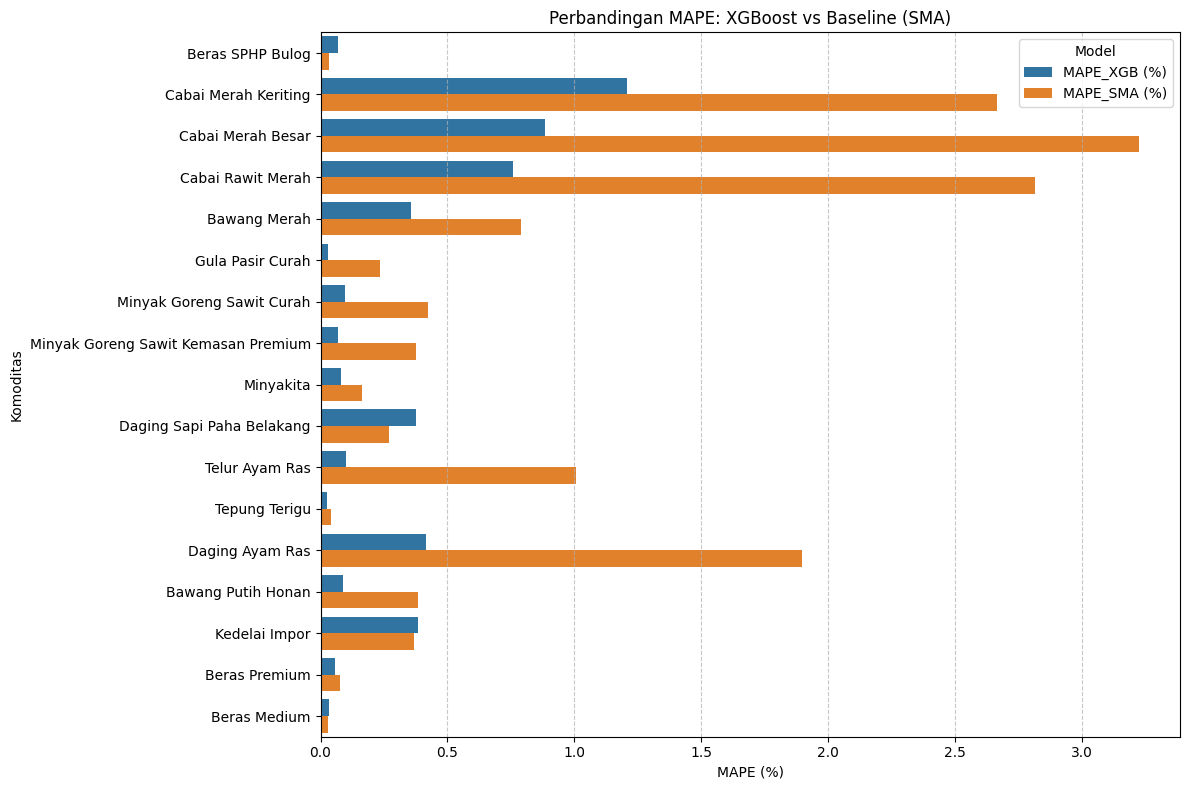

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menyiapkan data untuk plotting
df_plot = df_results.melt(id_vars='Variant', value_vars=['MAPE_XGB (%)', 'MAPE_SMA (%)'],
                          var_name='Model', value_name='MAPE')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_plot, x='MAPE', y='Variant', hue='Model')
plt.title('Perbandingan MAPE: XGBoost vs Baseline (SMA)')
plt.xlabel('MAPE (%)')
plt.ylabel('Komoditas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualisasi 2: Harga Aktual vs Prediksi (Beras Medium)
Grafik ini menunjukkan seberapa baik model mengikuti tren harga aktual pada data testing.

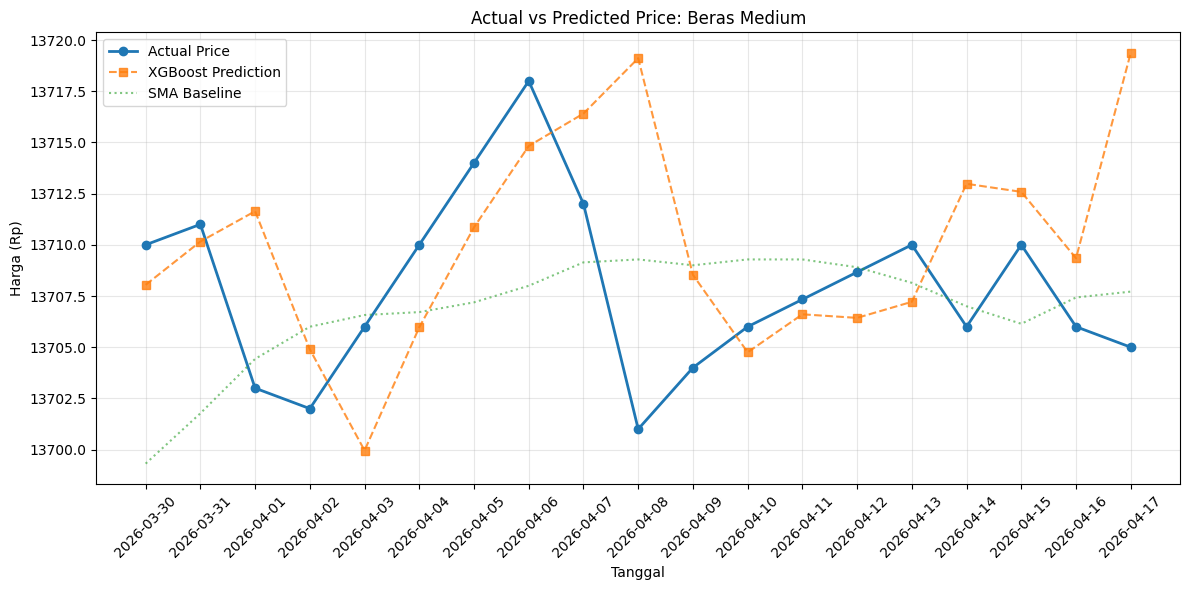

In [ ]:
# Kita ambil data evaluasi terakhir (Beras Medium) dari variabel eval_df yang ada di memory
plt.figure(figsize=(12, 6))
plt.plot(eval_df['tanggal'], eval_df['harga'], label='Actual Price', marker='o', linewidth=2)
plt.plot(eval_df['tanggal'], eval_df['y_pred_rupiah'], label='XGBoost Prediction', linestyle='--', marker='s', alpha=0.8)
plt.plot(eval_df['tanggal'], eval_df['y_pred_sma'], label='SMA Baseline', linestyle=':', alpha=0.6)

plt.title(f'Actual vs Predicted Price: {commodity_name}')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualisasi 3: Fitur Paling Berpengaruh (Feature Importance)
Grafik ini membantu menjelaskan faktor apa saja yang paling menentukan perubahan harga menurut model XGBoost.

C:\Users\Aditya\AppData\Local\Temp\ipykernel_700\3881589741.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='plasma')


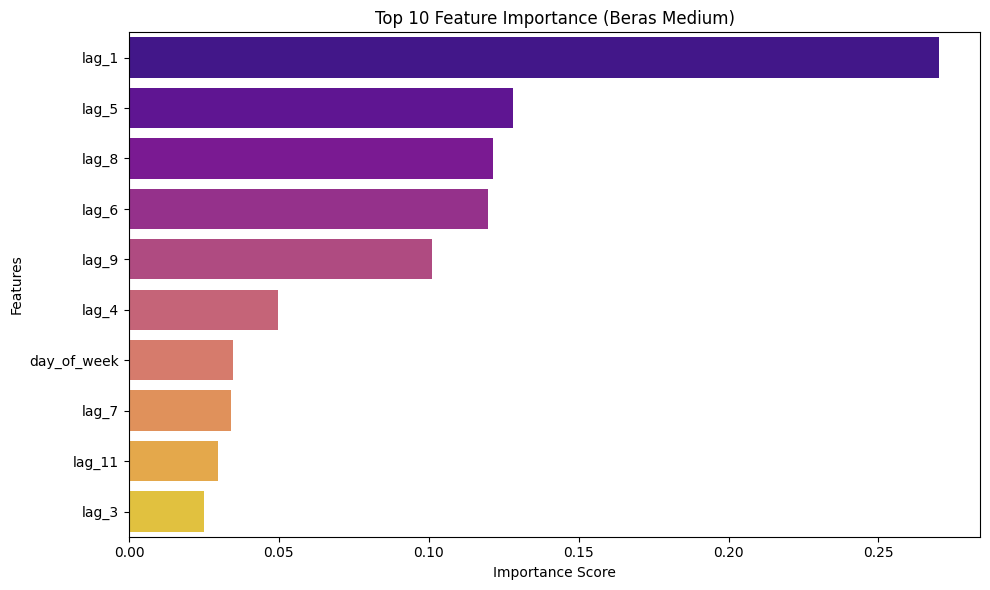

In [ ]:
# Mengambil feature importance dari model terakhir yang dilatih di loop
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='plasma')
plt.title(f'Top 10 Feature Importance ({commodity_name})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()